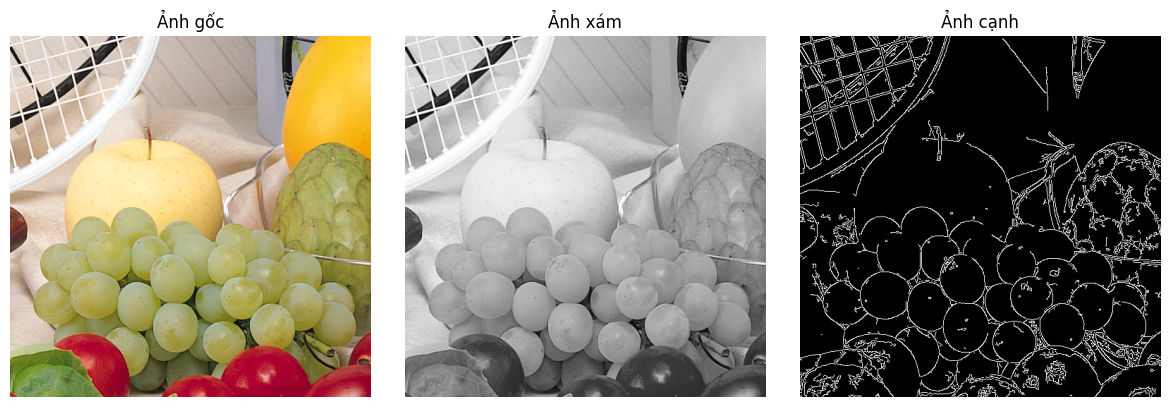

Kích thước ảnh gốc: (512, 512, 3)
Kích thước ảnh xám: (512, 512)
Kích thước ảnh biên: (512, 512)
Kiểu dữ liệu ảnh gốc: uint8
Kiểu dữ liệu ảnh xám: uint8
Kiểu dữ liệu ảnh biên: uint8
Số điểm ảnh biên: 20947
Tỉ lệ điểm ảnh biên: 0.07990646362304688


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: PHÁT HIỆN BIÊN BẰNG THUẬT TOÁN CANNY
# Chương/Mục liên quan: Chương 5 - Biên và đặc trưng cục bộ
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa bài toán phát hiện biên ảnh bằng thuật toán Canny.
# - Giúp người học quan sát sự thay đổi từ ảnh màu sang ảnh xám,
#   sau đó trích xuất biên từ ảnh xám.
# - Liên hệ phần code với bước tách biên trong xử lý ảnh và thị giác máy.

# Sau khi chạy code, người học cần:
# 1. Hiểu được vai trò của ảnh xám trong bài toán phát hiện biên.
# 2. Quan sát được biên là nơi cường độ sáng thay đổi mạnh.
# 3. Hiểu được ảnh hưởng của hai ngưỡng T_low và T_high trong Canny.

# Input:
# - Dữ liệu đầu vào: ảnh fruits.png từ GitHub
# - Kiểu dữ liệu: ảnh màu RGB

# Output:
# - Ảnh gốc
# - Ảnh xám
# - Ảnh biên thu được bằng thuật toán Canny

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def read_gitlab_image(url):
    resp = urlopen(url)
    img_num = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    img_BGR = cv2.imdecode(img_num, cv2.IMREAD_COLOR)
    return cv2.cvtColor(img_BGR, cv2.COLOR_BGR2RGB)

image_uri = "https://github.com/lthavnu/cv-book/raw/main/images/fruits.png"
image = read_gitlab_image(image_uri)

if image is None:
    raise FileNotFoundError("Không tìm thấy file fruits.png")

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

# Ảnh đầu vào sẽ được hiển thị cùng với ảnh xám và ảnh biên ở bước 5.

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# Chuyển ảnh màu RGB sang ảnh xám.
# Đây là bước tiền xử lý trước khi áp dụng thuật toán phát hiện biên.
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Thiết lập hai ngưỡng cho thuật toán Canny.
# T_low và T_high tương ứng với hai ngưỡng dùng trong bước ngưỡng kép.
T_low = 50
T_high = 150

# Áp dụng thuật toán Canny để phát hiện biên.
# Dòng code này là bước xử lý chính của bài toán.
edges = cv2.Canny(gray, T_low, T_high)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Ảnh xám")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edges, cmap="gray")
plt.title("Ảnh cạnh")
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

print("Kích thước ảnh gốc:", image.shape)
print("Kích thước ảnh xám:", gray.shape)
print("Kích thước ảnh biên:", edges.shape)

print("Kiểu dữ liệu ảnh gốc:", image.dtype)
print("Kiểu dữ liệu ảnh xám:", gray.dtype)
print("Kiểu dữ liệu ảnh biên:", edges.dtype)

print("Số điểm ảnh biên:", np.count_nonzero(edges))
print("Tỉ lệ điểm ảnh biên:", np.count_nonzero(edges) / edges.size)

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# Có thể thay đổi T_low và T_high để quan sát ảnh hưởng của ngưỡng kép.
# Ví dụ 1: T_low = 30, T_high = 100 có thể làm xuất hiện nhiều biên hơn.
# Ví dụ 2: T_low = 100, T_high = 200 có thể làm ảnh biên thưa hơn.
# Ví dụ 3: Thử các ảnh khác nhau để quan sát Canny hoạt động trên các loại ảnh khác nhau.